`Weather Temperature Prediction using RNN (LSTM)`

`Weather Forecast Time Series Prediction`

In [74]:
# !pip install tensorflow pandas numpy matplotlib scikit-learn streamlit joblib

In [75]:
from google.colab import files
files.upload()

'from google.colab import files\nfiles.upload()'

`Load Dataset`

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [77]:
data = pd.read_csv('/content/Daily_minimum_temps.csv')
data.head()

,Date,Temp
0,01/01/81,20.7
1,01/02/81,17.9
2,01/03/81,18.8
3,01/04/81,14.6
4,01/05/81,15.8


In [105]:
data.shape

(3647, 2)

In [78]:
print(data.dtypes)

Date    object
Temp    object
dtype: object


In [79]:
data.describe()

,Date,Temp
count,3650,3650
unique,3650,230
top,12/31/90,10
freq,1,51


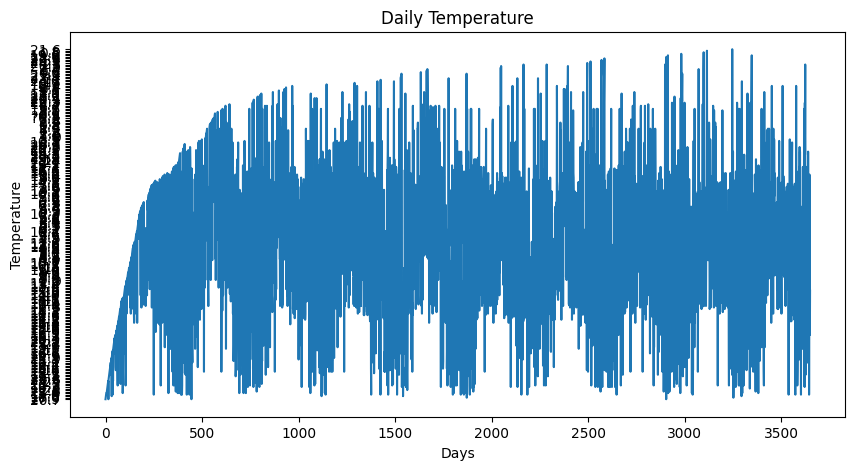

In [80]:
#plot the raw temparature
plt.figure(figsize=(10,5))
plt.plot(data['Temp'])
plt.title("Daily Temperature")
plt.xlabel("Days")
plt.ylabel("Temperature")
plt.show()

`Data Preprocessing`

In [81]:
data.isna().sum()

,0
Date,0
Temp,0


In [82]:
#invalid values → converted to NaN  e.g., ?0.2 -> NaN
data['Temp'] = pd.to_numeric(data['Temp'], errors='coerce')

In [83]:
#remove the missing value
data = data.dropna()

In [84]:
data.isna().sum() #check null value

,0
Date,0
Temp,0


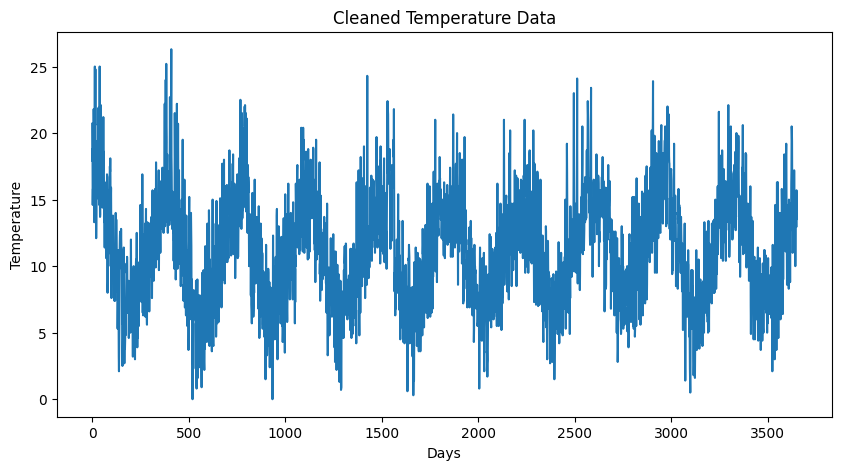

In [85]:
#plot cleaned data
plt.figure(figsize=(10,5))
plt.plot(data['Temp'])
plt.title("Cleaned Temperature Data")
plt.xlabel("Days")
plt.ylabel("Temperature")
plt.show()

In [86]:
#convert to Numpy
temps = data['Temp'].values.reshape(-1,1)

In [87]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
temps_scaled = scaler.fit_transform(temps)

In [88]:
#save Scaler file for web itegation
import joblib
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

`Create Sequence Dataset`

In [89]:
#used previoud 7days data to -> predict next day
def create_dataset(data, time_step=7):

    X = []
    y = []

    for i in range(len(data)-time_step):

        X.append(data[i:i+time_step])
        y.append(data[i+time_step])

    return np.array(X), np.array(y)

time_step = 7

X, y = create_dataset(temps_scaled,time_step)

In [90]:
print(X.shape)
print(y.shape)

(3640, 7, 1)
(3640, 1)


`Train Test Split`

In [91]:
train_size = int(len(X)*0.8)

X_train = X[:train_size] #lambda cut
y_train = y[:train_size]

X_test = X[train_size:]
y_test = y[train_size:]

`Build RNN (LSTM Model)`

In [92]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [93]:
model = Sequential([
    LSTM(64, input_shape=(7, 1)),  #size of complexity, input size
    Dense(32, activation='relu'),
    Dense(1, activation='linear')
])

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,009 (74.25 KB)

 Trainable params: 19,009 (74.25 KB)

 Non-trainable params: 0 (0.00 B)

`Train Model`

In [94]:
hist = model.fit( X_train, y_train, validation_data=(X_test,y_test), epochs=30, batch_size=32)

Epoch 1/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0386 - mae: 0.1378 - val_loss: 0.0101 - val_mae: 0.0787
Epoch 2/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0115 - mae: 0.0836 - val_loss: 0.0097 - val_mae: 0.0769
Epoch 3/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0111 - mae: 0.0823 - val_loss: 0.0094 - val_mae: 0.0757
Epoch 4/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0109 - mae: 0.0816 - val_loss: 0.0092 - val_mae: 0.0749
Epoch 5/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0108 - mae: 0.0809 - val_loss: 0.0088 - val_mae: 0.0731
Epoch 6/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0104 - mae: 0.0793 - val_loss: 0.0085 - val_mae: 0.0720
Epoch 7/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0102 - mae: 0.0788 - val_loss: 0.0084 - val_mae: 0.0718
Epoch 8/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0100 - mae: 0.0781 - val_loss: 0.0081 - val_mae: 0.0704
Epoch 9/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0099 - mae

In [95]:
print(hist.history.keys())

dict_keys(['loss', 'mae', 'val_loss', 'val_mae'])


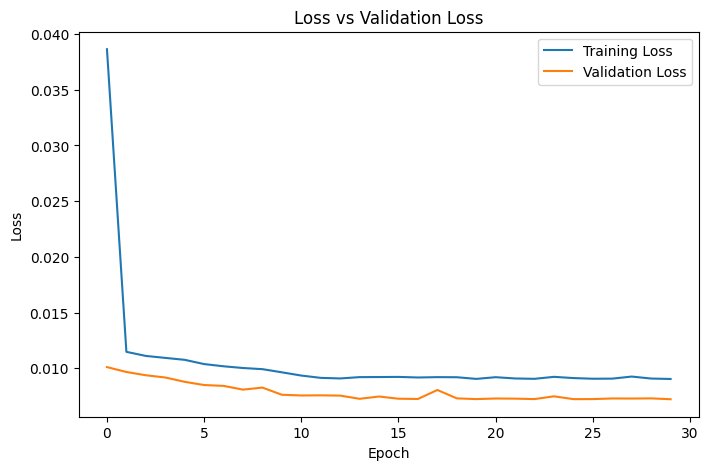

In [96]:
#plot loss and val_loss
plt.figure(figsize=(8,5))

plt.plot(hist.history['loss'],label="Training Loss") #model training loss
plt.plot(hist.history['val_loss'],label="Validation Loss") #testing loss

plt.title("Loss vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

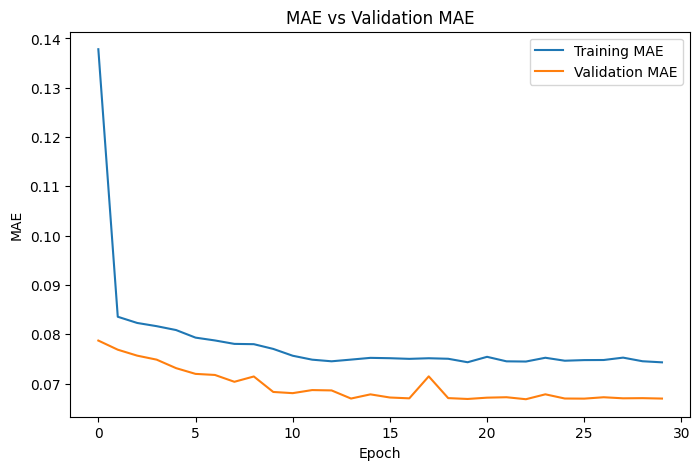

In [97]:
#plot MAE vs Validation MAE
plt.figure(figsize=(8,5))

plt.plot(hist.history['mae'],label="Training MAE") #training mae
plt.plot(hist.history['val_mae'],label="Validation MAE") #testing mae

plt.title("MAE vs Validation MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()

plt.show()

`Model Evaluation Metrics`

In [98]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

pred = model.predict(X_test)

mse = mean_squared_error(y_test,pred)

mae = mean_absolute_error(y_test,pred)

rmse = np.sqrt(mse)

print(f"MAE:{mae:.4f}")
print(f"MSE:{mse:.4f}")
print(f"RMSE:{rmse:.4f}")

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
MAE:0.0670
MSE:0.0072
RMSE:0.0850


`Plot Prediction vs Actual`

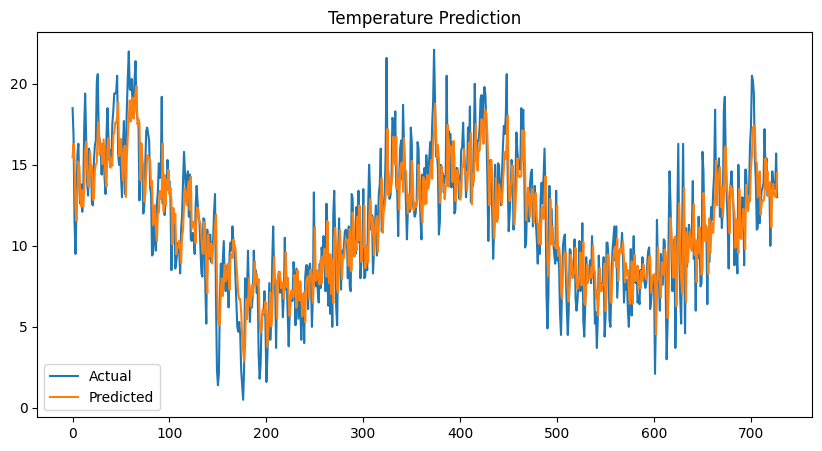

In [99]:
pred = scaler.inverse_transform(pred)
y_test_actual = scaler.inverse_transform(y_test)

plt.figure(figsize=(10,5))

plt.plot(y_test_actual,label="Actual")
plt.plot(pred,label="Predicted")

plt.title("Temperature Prediction")
plt.legend()

plt.show()

`Test`

In [106]:
def predict_temperature(model, scaler, temp_list):

    # Convert list to numpy array
    arr = np.array(temp_list).reshape(-1,1)

    # Scale the data
    arr_scaled = scaler.transform(arr)

    # Reshape for LSTM (samples, time_steps, features)
    arr_scaled = arr_scaled.reshape(1, len(temp_list), 1)

    # Predict
    pred_scaled = model.predict(arr_scaled)

    # Convert back to original temperature
    pred = scaler.inverse_transform(pred_scaled)

    return pred[0][0]

In [104]:
temps = []

for i in range(7):
    t = float(input(f"Enter temperature for Day {i+1}: "))
    temps.append(t)

prediction = predict_temperature(model, scaler, temps)

print(f"\nPredicted Temperature for Tomorrow: {prediction:.2f} °C")

Enter temperature for Day 1: 20.7
Enter temperature for Day 2: 17.9
Enter temperature for Day 3: 18.8
Enter temperature for Day 4: 14.6
Enter temperature for Day 5: 15.8
Enter temperature for Day 6: 15.8
Enter temperature for Day 7: 17.4
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step

Predicted Temperature for Tomorrow: 17.00 °C


`Save The Model`

In [102]:
model.save("weather_model.h5")